# redo topics...

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install gensim
!pip install --upgrade nltk

In [ ]:
import pandas as pd

In [ ]:
df_entrevistados_rotacion = pd.read_csv('/content/drive/MyDrive/Rotacion/output_data/df_entrevistados_rotacion.csv')
df_entrevistados_rotacion["num_empleado"]

,num_empleado
0,90097812
1,92650554
2,92109391
3,90391277
4,90269515
...,...
4665,91597901
4666,91966779
4667,92081983
4668,97238287


In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.corpora.dictionary import Dictionary
from gensim.models.ldamodel import LdaModel
import re

# Download necessary NLTK data (run this once)
# Using LookupError is more robust for missing packages
try:
    nltk.data.find('corpora/wordnet')
    nltk.data.find('corpora/stopwords')
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("NLTK data not found. Downloading 'wordnet', 'stopwords', and 'punkt'...")
    nltk.download('wordnet')
    nltk.download('stopwords')
    nltk.download('punkt')

# --- Configuration (rest of your script follows) ---
# Initialize Lemmatizer and Stop Words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('spanish'))

def preprocess_text(text, pos):
    """
    Performs tokenization, cleaning, stop word removal, and lemmatization.
    """
    # 1. Clean and Tokenize (convert to lowercase and remove non-alphabetic chars)
    text = str(text).lower()
    tokens = re.findall(r'\b[a-z]{2,}\b', text) # Get words with 3 or more chars

    # 2. Remove Stop Words and Lemmatize
    lemmas = []
    for token in tokens:
        if token not in stop_words:
            # We assume 'n' (noun) as the default POS, but a proper POS tagger
            # would make lemmatization more accurate.
            lemma = lemmatizer.lemmatize(token, pos=pos)
            lemmas.append(lemma)

    return lemmas

def perform_topic_modeling(df, text_column, num_topics, num_words, pos, get_model=False, prev_model=None):
    """
    Applies preprocessing, creates the corpus, and runs the LDA model.
    """
    print("Starting text preprocessing (Lemmatization & Cleaning)...")

    # Apply preprocessing function to the text column
    df['processed_text'] = df[text_column].apply(lambda x: preprocess_text(x, pos))

    # Prepare data for Gensim
    texts = df['processed_text'].tolist()

    # 1. Create a Dictionary (mapping of word to unique ID)
    dictionary = Dictionary(texts)
    # Filter out words that appear in less than 15 documents
    # and in more than 50% of documents (a common best practice)
    dictionary.filter_extremes(no_below=15, no_above=0.5)

    # 2. Create a Corpus (Bag-of-Words representation)
    corpus = [dictionary.doc2bow(text) for text in texts]

    print(f"Corpus size: {len(corpus)} documents")
    print(f"Vocabulary size: {len(dictionary)} unique words")
    print("\nTraining LDA Topic Model...")

    # 3. Train the LDA Model
    # Note: Training time increases with data size and number of iterations (passes)
    if prev_model:
      lda_model = prev_model
    else:
      lda_model = LdaModel(
          corpus=corpus,
          id2word=dictionary,
          num_topics=num_topics,
          random_state=100,
          passes=10, # Number of passes through the corpus
          alpha='auto',
          eta='auto'
      )

    # Get the topics and their most representative words
    topics = lda_model.print_topics(num_words=num_words)

    ress = []
    for i, doc in enumerate(corpus):
        # Get the topic distribution for the document
        doc_topics = lda_model.get_document_topics(doc)
        ress.append(doc_topics)
        # Format the output for readability
        formatted_topics = ", ".join([f"Topic {tid}: {prob:.2f}" for tid, prob in doc_topics])
        # print(f"Document {i+1}: {formatted_topics}")
    if get_model:
      return ress, topics, lda_model
    return ress, topics

def print_topics(topics):
  for topic_id, topic_words in topics:
    # topic_words is a string like '0.050*"word1" + 0.040*"word2" ...'
    print(f"Topic #{topic_id}: {topic_words}")
  return None

def print_ress(ress):
  print(f"Formatted_topics")
  for doc_topics in ress:
    formatted_topics = ", ".join([f"Topic {tid}: {prob:.2f}" for tid, prob in doc_topics])
    print(formatted_topics)
  return None




NLTK data not found. Downloading 'wordnet', 'stopwords', and 'punkt'...


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
# --- Configuration ---
CSV_FILE = '/content/drive/MyDrive/Rotacion/input_data/Copy of Sondeo  -   Perspectiva del Gerente sobre Rotación  (Respuestas) - Respuestas de formulario 1.csv'  # <-- **CHANGE THIS TO YOUR CSV FILE NAME**
NUM_TOPICS = 6  # Number of topics to discover
NUM_WORDS = 6  # Number of words to display for each topic
# 6 en lugar de 10 para forzar al modelo a encontrar palabras mas variadas y mas significativas, reducir
# ---------------------

# --- Main Execution ---
res_dict = {}
top_dict = {}
# Load the CSV file
data = pd.read_csv(CSV_FILE)

In [ ]:
data = data[data["num_empleado"].isin(df_entrevistados_rotacion["num_empleado"])] # solo cierto num_empleado s
data = data.drop_duplicates(subset=['num_empleado'], keep='first') # quitar duplicados
data.shape

(4670, 9)

In [ ]:
models = {}
for pregunta_idx in range(1,7):
  TEXT_COLUMN = f'P{pregunta_idx}' # <-- **CHANGE THIS TO YOUR TEXT COLUMN NAME**
  models[pregunta_idx] = {}
  for pos in ["n"]:
    if pregunta_idx==3:
      this_ress, this_topics, this_model = perform_topic_modeling(data, TEXT_COLUMN, NUM_TOPICS, NUM_WORDS, pos, get_model=True, prev_model=models[2]["P2_"+pos])
    else:
      this_ress, this_topics, this_model = perform_topic_modeling(data, TEXT_COLUMN, NUM_TOPICS, NUM_WORDS, pos, get_model=True)
    models[pregunta_idx][TEXT_COLUMN+"_"+pos] = this_model
    res_dict[TEXT_COLUMN+"_"+pos] = this_ress
    top_dict[TEXT_COLUMN+"_"+pos] = this_topics
    # ress = perform_topic_modeling(data, TEXT_COLUMN, NUM_TOPICS, NUM_WORDS, "n")


Starting text preprocessing (Lemmatization & Cleaning)...
Corpus size: 4670 documents
Vocabulary size: 167 unique words

Training LDA Topic Model...
Starting text preprocessing (Lemmatization & Cleaning)...
Corpus size: 4670 documents
Vocabulary size: 345 unique words

Training LDA Topic Model...
Starting text preprocessing (Lemmatization & Cleaning)...
Corpus size: 4670 documents
Vocabulary size: 307 unique words

Training LDA Topic Model...
Starting text preprocessing (Lemmatization & Cleaning)...
Corpus size: 4670 documents
Vocabulary size: 376 unique words

Training LDA Topic Model...
Starting text preprocessing (Lemmatization & Cleaning)...
Corpus size: 4670 documents
Vocabulary size: 387 unique words

Training LDA Topic Model...
Starting text preprocessing (Lemmatization & Cleaning)...
Corpus size: 4670 documents
Vocabulary size: 378 unique words

Training LDA Topic Model...


In [ ]:
AAA = pd.DataFrame(res_dict)
AAA


,P1_n,P2_n,P3_n,P4_n,P5_n,P6_n
0,"[(0, 0.05679833), (1, 0.08189993), (2, 0.06701...","[(0, 0.33122358), (1, 0.05679749), (2, 0.06074...","[(0, 0.027455864), (1, 0.033992782), (2, 0.036...","[(0, 0.077989295), (1, 0.06297558), (2, 0.6161...","[(0, 0.035520166), (1, 0.2847265), (2, 0.03537...","[(0, 0.24746653), (1, 0.021097004), (2, 0.0268..."
1,"[(0, 0.017537015), (1, 0.7165405), (2, 0.02069...","[(0, 0.23844433), (1, 0.028308587), (2, 0.0308...","[(0, 0.22413537), (1, 0.37142143), (2, 0.01832...","[(0, 0.05055325), (1, 0.39094725), (2, 0.05080...","[(0, 0.5545505), (1, 0.016483717), (2, 0.35312...","[(0, 0.014677415), (1, 0.013923476), (2, 0.017..."
2,"[(0, 0.024303975), (1, 0.037352953), (2, 0.028...","[(0, 0.2851629), (1, 0.5442332), (2, 0.0454726...","[(0, 0.7156561), (1, 0.056918457), (2, 0.06072...","[(0, 0.8958539), (1, 0.017059945), (2, 0.02116...","[(0, 0.03552269), (1, 0.02911779), (2, 0.03537...","[(0, 0.066950604), (1, 0.34432554), (3, 0.4764..."
3,"[(0, 0.03923196), (1, 0.05657025), (2, 0.04656...","[(0, 0.045489863), (1, 0.39199114), (2, 0.0618...","[(0, 0.0454654), (1, 0.056795202), (2, 0.06107...","[(0, 0.47654164), (1, 0.013202642), (2, 0.0163...","[(0, 0.3664552), (1, 0.039116498), (2, 0.04759...","[(0, 0.15431394), (1, 0.14644133), (2, 0.18483..."
4,"[(0, 0.039231867), (1, 0.05656994), (2, 0.0466...","[(0, 0.7156229), (1, 0.056918632), (2, 0.06072...","[(0, 0.0454627), (1, 0.056797747), (2, 0.39615...","[(0, 0.037521273), (1, 0.80750644), (2, 0.0376...","[(0, 0.047711056), (1, 0.72558343), (2, 0.0475...","[(0, 0.022195399), (1, 0.021079708), (2, 0.589..."
...,...,...,...,...,...,...
4665,"[(0, 0.017544148), (1, 0.23441198), (2, 0.3365...","[(0, 0.0340415), (1, 0.042903442), (2, 0.49676...","[(0, 0.01364686), (1, 0.34249264), (2, 0.43513...","[(0, 0.24149491), (1, 0.5469018), (2, 0.183068...","[(0, 0.023509024), (1, 0.019269325), (2, 0.208...","[(0, 0.2677826), (1, 0.013918162), (2, 0.01759..."
4666,"[(0, 0.02996464), (1, 0.04321582), (2, 0.03535...","[(0, 0.5712566), (1, 0.08546249), (2, 0.093016...","[(0, 0.034142304), (1, 0.04253156), (2, 0.4974...","[(0, 0.018390082), (1, 0.014897177), (2, 0.175...","[(0, 0.023536235), (1, 0.019278577), (2, 0.023...","[(0, 0.8145904), (1, 0.032051183), (2, 0.04058..."
4667,"[(0, 0.01753694), (1, 0.025307052), (2, 0.2980...","[(0, 0.01950437), (1, 0.024356807), (2, 0.0259...","[(0, 0.13930464), (1, 0.11721339), (2, 0.34769...","[(0, 0.0246569), (1, 0.01996535), (2, 0.877817...","[(0, 0.04772003), (1, 0.039109014), (2, 0.0475...","[(0, 0.15431394), (1, 0.14644133), (2, 0.18483..."
4668,"[(0, 0.024238886), (1, 0.034956362), (2, 0.028...","[(0, 0.03414579), (1, 0.042529903), (2, 0.5478...","[(0, 0.03410306), (1, 0.04252958), (2, 0.04565...","[(0, 0.60438156), (1, 0.017053343), (2, 0.0211...","[(0, 0.02355235), (1, 0.01929077), (2, 0.29549...","[(0, 0.01466327), (1, 0.013924204), (2, 0.0176..."


In [ ]:
cols = AAA.columns
all_new_row = []
for idx, this_row in AAA.iterrows():
  new_row = []
  for ress in this_row:
    ress = dict(ress)
    for idx in range(6):
      new_row.append(ress.get(idx, 0.0))
  all_new_row.append(new_row)

new_cols = [col+"_"+str(idx) for col in cols for idx in range(6)]

new_df = pd.DataFrame(all_new_row, columns=new_cols)



In [ ]:
new_df

,P1_n_0,P1_n_1,P1_n_2,P1_n_3,P1_n_4,P1_n_5,P2_n_0,P2_n_1,P2_n_2,P2_n_3,...,P5_n_2,P5_n_3,P5_n_4,P5_n_5,P6_n_0,P6_n_1,P6_n_2,P6_n_3,P6_n_4,P6_n_5
0,0.056798,0.081900,0.067019,0.068534,0.104534,0.621214,0.331224,0.056797,0.060742,0.433563,...,0.035373,0.049284,0.550124,0.044972,0.247467,0.021097,0.026831,0.019896,0.661277,0.023433
1,0.017537,0.716541,0.020690,0.159397,0.032275,0.053561,0.238444,0.028309,0.030864,0.024230,...,0.353120,0.026797,0.023445,0.025603,0.014677,0.013923,0.017715,0.013151,0.655124,0.285410
2,0.024304,0.037353,0.028850,0.029247,0.615523,0.264724,0.285163,0.544233,0.045473,0.036398,...,0.035375,0.302773,0.297007,0.300204,0.066951,0.344326,0.000000,0.476401,0.010221,0.093330
3,0.039232,0.056570,0.046568,0.047338,0.381376,0.428915,0.045490,0.391991,0.061886,0.048472,...,0.047598,0.429783,0.055591,0.061457,0.154314,0.146441,0.184833,0.138176,0.213832,0.162404
4,0.039232,0.056570,0.046656,0.047336,0.690388,0.119819,0.715623,0.056919,0.060721,0.048471,...,0.047513,0.063233,0.055553,0.060407,0.022195,0.021080,0.589678,0.019902,0.030877,0.316268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4665,0.017544,0.234412,0.336561,0.021201,0.204689,0.185593,0.034042,0.042903,0.496764,0.036389,...,0.208212,0.031509,0.027372,0.690129,0.267783,0.013918,0.017600,0.013135,0.356125,0.331439
4666,0.029965,0.043216,0.035354,0.260079,0.058714,0.572672,0.571257,0.085462,0.093016,0.073174,...,0.023414,0.876574,0.027423,0.029774,0.814590,0.032051,0.040583,0.030236,0.046921,0.035618
4667,0.017537,0.025307,0.298045,0.295597,0.034236,0.329277,0.019504,0.024357,0.025990,0.366544,...,0.047513,0.749696,0.055554,0.060408,0.154314,0.146441,0.184833,0.138176,0.213832,0.162404
4668,0.024239,0.034956,0.028600,0.029519,0.553487,0.329199,0.034146,0.042530,0.547823,0.036297,...,0.295492,0.031921,0.599829,0.029915,0.014663,0.013924,0.017659,0.570834,0.020426,0.362493


In [ ]:
# this_res = AAA["P1_n"].tolist()
# print_ress(this_res)
# pd.DataFrame(top_dict).to_pickle("/content/drive/MyDrive/Rotacion/topic_modelling/topics_dict.pkl")

In [ ]:
top_df = pd.DataFrame(top_dict)
# top_df.columns
for col in top_df:
  print("columns:", col)
  print(print_topics(top_df[col].tolist()))
# this_topic = pd.DataFrame(top_dict)["P1_n"].tolist()
# print_topics(this_topic)

columns: P1_n
Topic #0: 0.066*"trabajo" + 0.041*"tener" + 0.041*"comodidad" + 0.036*"ser" + 0.036*"trabajar" + 0.035*"puesto"
Topic #1: 0.134*"trabajo" + 0.111*"coppel" + 0.077*"gusta" + 0.069*"compromiso" + 0.058*"persona" + 0.051*"responsabilidad"
Topic #2: 0.193*"laboral" + 0.162*"ambiente" + 0.093*"buen" + 0.085*"necesidad" + 0.073*"personal" + 0.071*"trabajo"
Topic #3: 0.406*"empresa" + 0.045*"valores" + 0.043*"buena" + 0.041*"colaboradores" + 0.039*"brinda" + 0.038*"resultados"
Topic #4: 0.205*"estabilidad" + 0.125*"empresa" + 0.098*"crecimiento" + 0.086*"laboral" + 0.081*"beneficios" + 0.050*"oportunidades"
Topic #5: 0.690*"prestaciones" + 0.049*"buenas" + 0.048*"sueldo" + 0.041*"trato" + 0.023*"ofrece" + 0.015*"incentivos"
None
columns: P2_n
Topic #0: 0.092*"laboral" + 0.047*"metas" + 0.043*"exigencia" + 0.035*"jornada" + 0.032*"trato" + 0.025*"jefes"
Topic #1: 0.161*"horario" + 0.157*"horarios" + 0.123*"sueldo" + 0.053*"trabajo" + 0.039*"mejor" + 0.034*"pago"
Topic #2: 0.148*"

In [ ]:
long_a_str = """
column: P1_n
question: 1. ¿Qué crees que ha hecho que algunas personas lleven tanto tiempo en la empresa?
lemm: nouns
titled topic 0: comodidad_en_el_trabajo
titled topic 1: compromiso_con_la_empresa
titled topic 2: buen_ambiente_laboral
titled topic 3: valores_de_la_empresa
titled topic 4: estabilidad_y_crecimiento_laboral
titled topic 5: prestaciones_y_sueldo

column: P2_n
question: 2. ¿A qué atribuyes que algunos Colaboradores renuncien teniendo poco tiempo laborando en la empresa?
lemm: nouns
titled topic 0: exigencia_laboral_y_trato_jefes
titled topic 1: horarios_y_sueldo
titled topic 2: carga_de_trabajo_y_tiempo_personal
titled topic 3: busqueda_de_mejores_prestaciones
titled topic 4: disgusto_con_actividades_laborales
titled topic 5: falta_de_compromiso_y_responsabilidad

column: P3_n
question: 3. ¿A qué atribuyes que algunos Colaboradores renuncien teniendo mucho tiempo laborando en la empresa?
lemm: nouns
titled topic 0: exigencia_laboral_y_trato_jefes
titled topic 1: horarios_y_sueldo
titled topic 2: carga_de_trabajo_y_tiempo_personal
titled topic 3: busqueda_de_mejores_prestaciones
titled topic 4: disgusto_con_actividades_laborales
titled topic 5: falta_de_compromiso_o_mejores_ofertas

column: P4_n
question: 4. ¿Qué condiciones internas y/o del entorno (de la localidad) hacen que liderar este centro sea más retador que otros?
lemm: nouns
titled topic 0: competencia_laboral_sueldos_horarios
titled topic 1: gestion_del_centro_y_metas
titled topic 2: poca_afluencia_de_clientes
titled topic 3: ubicacion_tienda_y_competencia_zona
titled topic 4: cultura_de_trabajo_y_equipo
titled topic 5: falta_de_personal

column: P5_n
question: 5. ¿Qué apoyos, decisiones o herramientas (internas o externas) podrían ayudar a mejorar la permanencia?
lemm: nouns
titled topic 0: seguimiento_y_entrenamiento_colaborador
titled topic 1: apoyo_gerentes_y_desarrollo
titled topic 2: incentivos_para_metas
titled topic 3: bienestar_del_colaborador
titled topic 4: mejores_prestaciones_y_sueldos
titled topic 5: mejora_horarios_y_sueldo

column: P6_n
question: 6. ¿Hay algo que no te hayamos preguntado y que consideres importante agregar para poder comprender por qué los Colaboradores toman la decisión de salir de la empresa?
lemm: nouns
titled topic 0: sin_comentarios_o_tema_horarios
titled topic 1: sueldo_e_incentivos
titled topic 2: todo_bien_sin_comentarios
titled topic 3: temas_generales_colaboradores
titled topic 4: trabajo_personal_y_metas
titled topic 5: relacion_gerentes_colaboradores
"""

In [ ]:
colss = []
for col in long_a_str.split("\n"):
  if "titled topic " in col:
    colss.append(col.split(": ")[1])


In [ ]:
colss

['comodidad_en_el_trabajo',
 'compromiso_con_la_empresa',
 'buen_ambiente_laboral',
 'valores_de_la_empresa',
 'estabilidad_y_crecimiento_laboral',
 'prestaciones_y_sueldo',
 'exigencia_laboral_y_trato_jefes',
 'horarios_y_sueldo',
 'carga_de_trabajo_y_tiempo_personal',
 'busqueda_de_mejores_prestaciones',
 'disgusto_con_actividades_laborales',
 'falta_de_compromiso_y_responsabilidad',
 'exigencia_laboral_y_trato_jefes',
 'horarios_y_sueldo',
 'carga_de_trabajo_y_tiempo_personal',
 'busqueda_de_mejores_prestaciones',
 'disgusto_con_actividades_laborales',
 'falta_de_compromiso_o_mejores_ofertas',
 'competencia_laboral_sueldos_horarios',
 'gestion_del_centro_y_metas',
 'poca_afluencia_de_clientes',
 'ubicacion_tienda_y_competencia_zona',
 'cultura_de_trabajo_y_equipo',
 'falta_de_personal',
 'seguimiento_y_entrenamiento_colaborador',
 'apoyo_gerentes_y_desarrollo',
 'incentivos_para_metas',
 'bienestar_del_colaborador',
 'mejores_prestaciones_y_sueldos',
 'mejora_horarios_y_sueldo',
 's

#start from here

In [ ]:
import pickle
# # save vars
# new_df.to_csv("/content/drive/MyDrive/Rotacion/topic_modelling/LDA_res_new.csv", index=False)
# with open('/content/drive/MyDrive/Rotacion/topic_modelling/top_dict_new.pkl', 'wb') as file:
#     pickle.dump(top_dict, file)
# with open("/content/drive/MyDrive/Rotacion/output_data/topic_names_new.pkl", "wb") as f:
#     pickle.dump(colss, f)


# # RELOAD VARIABLES
# new_df = pd.read_csv("/content/drive/MyDrive/Rotacion/topic_modelling/LDA_res.csv")
# with open("/content/drive/MyDrive/Rotacion/topic_modelling/top_dict_new.pkl", "rb") as file:
#         top_dict = pickle.load(file)
# with open("/content/drive/MyDrive/Rotacion/output_data/topic_names_new.pkl", "rb") as f:
#     colss = pickle.load(f)


In [ ]:
## set topic names
# import pickle
# file_path = "/content/drive/MyDrive/Rotacion/output_data/topic_names.pkl"
# with open(file_path, "rb") as f:
#         colss = pickle.load(f)
# colss
n = len(colss)
print("n", n)
for idx, tupp in enumerate(zip(new_df.columns, colss)):
  colss[idx] = tupp[0]+"_"+tupp[1]
for col in new_df.columns[72:]:
  colss.append(col)
new_df.columns = colss

n 36


In [ ]:
new_df

,P1_n_0_comodidad_en_el_trabajo,P1_n_1_compromiso_con_la_empresa,P1_n_2_buen_ambiente_laboral,P1_n_3_valores_de_la_empresa,P1_n_4_estabilidad_y_crecimiento_laboral,P1_n_5_prestaciones_y_sueldo,P2_n_0_exigencia_laboral_y_trato_jefes,P2_n_1_horarios_y_sueldo,P2_n_2_carga_de_trabajo_y_tiempo_personal,P2_n_3_busqueda_de_mejores_prestaciones,...,P5_n_2_incentivos_para_metas,P5_n_3_bienestar_del_colaborador,P5_n_4_mejores_prestaciones_y_sueldos,P5_n_5_mejora_horarios_y_sueldo,P6_n_0_sin_comentarios_o_tema_horarios,P6_n_1_sueldo_e_incentivos,P6_n_2_todo_bien_sin_comentarios,P6_n_3_temas_generales_colaboradores,P6_n_4_trabajo_personal_y_metas,P6_n_5_relacion_gerentes_colaboradores
0,0.056798,0.081900,0.067019,0.068534,0.104534,0.621214,0.331224,0.056797,0.060742,0.433563,...,0.035373,0.049284,0.550124,0.044972,0.247467,0.021097,0.026831,0.019896,0.661277,0.023433
1,0.017537,0.716541,0.020690,0.159397,0.032275,0.053561,0.238444,0.028309,0.030864,0.024230,...,0.353120,0.026797,0.023445,0.025603,0.014677,0.013923,0.017715,0.013151,0.655124,0.285410
2,0.024304,0.037353,0.028850,0.029247,0.615523,0.264724,0.285163,0.544233,0.045473,0.036398,...,0.035375,0.302773,0.297007,0.300204,0.066951,0.344326,0.000000,0.476401,0.010221,0.093330
3,0.039232,0.056570,0.046568,0.047338,0.381376,0.428915,0.045490,0.391991,0.061886,0.048472,...,0.047598,0.429783,0.055591,0.061457,0.154314,0.146441,0.184833,0.138176,0.213832,0.162404
4,0.039232,0.056570,0.046656,0.047336,0.690388,0.119819,0.715623,0.056919,0.060721,0.048471,...,0.047513,0.063233,0.055553,0.060407,0.022195,0.021080,0.589678,0.019902,0.030877,0.316268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4665,0.017544,0.234412,0.336561,0.021201,0.204689,0.185593,0.034042,0.042903,0.496764,0.036389,...,0.208212,0.031509,0.027372,0.690129,0.267783,0.013918,0.017600,0.013135,0.356125,0.331439
4666,0.029965,0.043216,0.035354,0.260079,0.058714,0.572672,0.571257,0.085462,0.093016,0.073174,...,0.023414,0.876574,0.027423,0.029774,0.814590,0.032051,0.040583,0.030236,0.046921,0.035618
4667,0.017537,0.025307,0.298045,0.295597,0.034236,0.329277,0.019504,0.024357,0.025990,0.366544,...,0.047513,0.749696,0.055554,0.060408,0.154314,0.146441,0.184833,0.138176,0.213832,0.162404
4668,0.024239,0.034956,0.028600,0.029519,0.553487,0.329199,0.034146,0.042530,0.547823,0.036297,...,0.295492,0.031921,0.599829,0.029915,0.014663,0.013924,0.017659,0.570834,0.020426,0.362493


## calcular estadisticos de topicos...

In [ ]:
def get_topics(df, question_n, pos):
  return df.loc[:,df.columns.str.contains(f"P{question_n}_{pos}")].copy()

In [ ]:
# get_topics(new_df, 1, "n")

In [ ]:
def rank_topics(df_topics):
  ranks = []
  for idx, row in df_topics.iterrows():
    row = row.tolist()
    non_unique = (len(set(row)) !=  6)
    if non_unique:
      print("NON UNIQUE VALUES:", idx, "\n", row)
    ranks.append(sorted(range(len(row)), key=lambda k: row[k], reverse=True))
  ranks = pd.DataFrame(ranks, columns=["1ra","2da","3ra","4ta","5ta","6ta"])
  return ranks

In [ ]:
rankss = []
for question_n in range(1,7):
  for pos in ["n"]:
    question_top_df = get_topics(new_df, question_n, pos)
    rankss.append(rank_topics(question_top_df))

NON UNIQUE VALUES: 1224 
 [0.22163018584251404, 0.09705901890993118, 0.0, 0.0, 0.5143536925315857, 0.14824040234088898]
NON UNIQUE VALUES: 1761 
 [0.0, 0.4659879505634308, 0.0, 0.1369471251964569, 0.01546529121696949, 0.3634472191333771]
NON UNIQUE VALUES: 2803 
 [0.22142919898033142, 0.1776503324508667, 0.0, 0.0, 0.558284342288971, 0.023903075605630875]
NON UNIQUE VALUES: 3239 
 [0.16813020408153534, 0.6379989981651306, 0.0, 0.0, 0.1514204889535904, 0.024772724136710167]
NON UNIQUE VALUES: 3469 
 [0.0, 0.4563293159008026, 0.0, 0.1833212822675705, 0.19856932759284973, 0.14570418000221252]
NON UNIQUE VALUES: 4193 
 [0.0, 0.5754087567329407, 0.0, 0.12743592262268066, 0.2032093107700348, 0.07947493344545364]
NON UNIQUE VALUES: 11 
 [0.0, 0.07372677326202393, 0.29284000396728516, 0.0, 0.6043621301651001, 0.011521921493113041]
NON UNIQUE VALUES: 231 
 [0.0, 0.12522633373737335, 0.26458972692489624, 0.5856705904006958, 0.0, 0.0]
NON UNIQUE VALUES: 375 
 [0.0, 0.0, 0.0, 0.5716754198074341, 0.

In [ ]:
def print_rank_res(rankss, questions=range(6)):
  corresponding_topics = []
  for question_idx in range(6):
    print("Histogramas para la pregunta N."+ str(question_idx+1)+ ". Lemm: n ")
    rankss[question_idx].hist()
    plt.show()
    print()
    this_corresponding_topics = new_df.columns[(question_idx*6):((question_idx+1)*6)]
    print(this_corresponding_topics)
    corresponding_topics.append(this_corresponding_topics)
  return corresponding_topics

Histogramas para la pregunta N.1. Lemm: n 


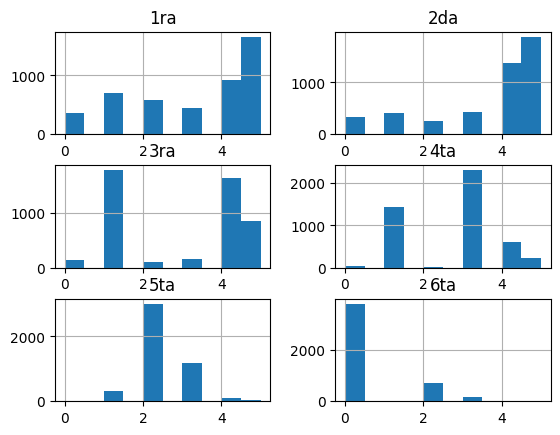


Index(['P1_n_0_comodidad_en_el_trabajo', 'P1_n_1_compromiso_con_la_empresa',
       'P1_n_2_buen_ambiente_laboral', 'P1_n_3_valores_de_la_empresa',
       'P1_n_4_estabilidad_y_crecimiento_laboral',
       'P1_n_5_prestaciones_y_sueldo'],
      dtype='object')
Histogramas para la pregunta N.2. Lemm: n 


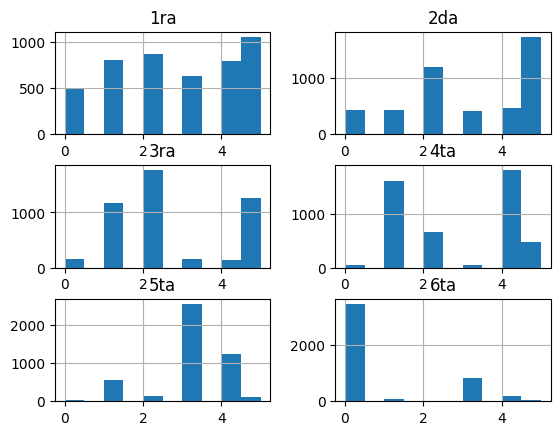


Index(['P2_n_0_exigencia_laboral_y_trato_jefes', 'P2_n_1_horarios_y_sueldo',
       'P2_n_2_carga_de_trabajo_y_tiempo_personal',
       'P2_n_3_busqueda_de_mejores_prestaciones',
       'P2_n_4_disgusto_con_actividades_laborales',
       'P2_n_5_falta_de_compromiso_y_responsabilidad'],
      dtype='object')
Histogramas para la pregunta N.3. Lemm: n 


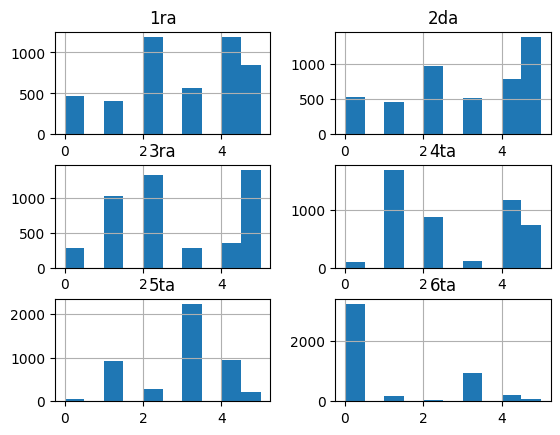


Index(['P3_n_0_exigencia_laboral_y_trato_jefes', 'P3_n_1_horarios_y_sueldo',
       'P3_n_2_carga_de_trabajo_y_tiempo_personal',
       'P3_n_3_busqueda_de_mejores_prestaciones',
       'P3_n_4_disgusto_con_actividades_laborales',
       'P3_n_5_falta_de_compromiso_o_mejores_ofertas'],
      dtype='object')
Histogramas para la pregunta N.4. Lemm: n 


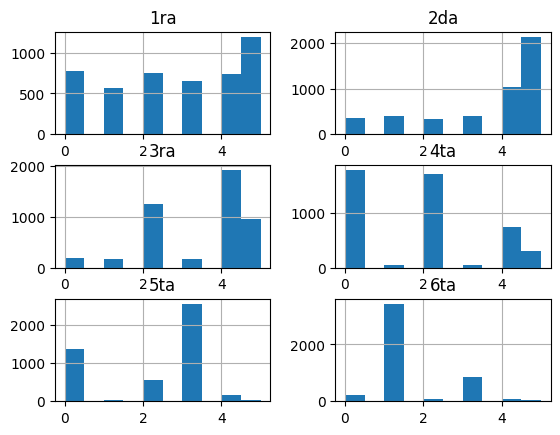


Index(['P4_n_0_competencia_laboral_sueldos_horarios',
       'P4_n_1_gestion_del_centro_y_metas',
       'P4_n_2_poca_afluencia_de_clientes',
       'P4_n_3_ubicacion_tienda_y_competencia_zona',
       'P4_n_4_cultura_de_trabajo_y_equipo', 'P4_n_5_falta_de_personal'],
      dtype='object')
Histogramas para la pregunta N.5. Lemm: n 


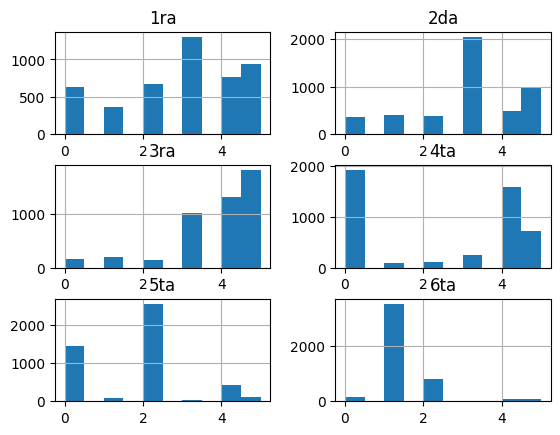


Index(['P5_n_0_seguimiento_y_entrenamiento_colaborador',
       'P5_n_1_apoyo_gerentes_y_desarrollo', 'P5_n_2_incentivos_para_metas',
       'P5_n_3_bienestar_del_colaborador',
       'P5_n_4_mejores_prestaciones_y_sueldos',
       'P5_n_5_mejora_horarios_y_sueldo'],
      dtype='object')
Histogramas para la pregunta N.6. Lemm: n 


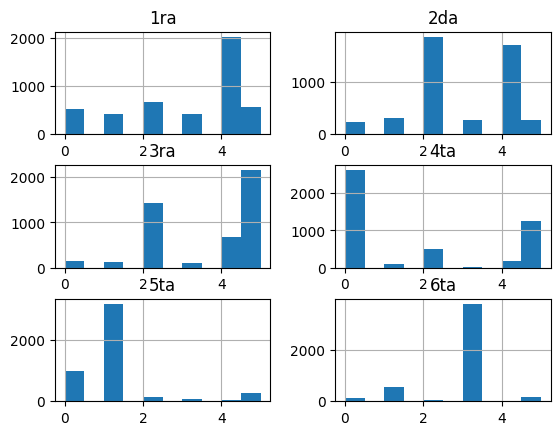


Index(['P6_n_0_sin_comentarios_o_tema_horarios', 'P6_n_1_sueldo_e_incentivos',
       'P6_n_2_todo_bien_sin_comentarios',
       'P6_n_3_temas_generales_colaboradores',
       'P6_n_4_trabajo_personal_y_metas',
       'P6_n_5_relacion_gerentes_colaboradores'],
      dtype='object')


In [ ]:
import matplotlib.pyplot as plt
corresponding_topics = print_rank_res(rankss)

In [ ]:
from scipy import stats

In [ ]:
ranks_corrs = list(map(lambda x: stats.spearmanr(x.to_numpy()), rankss))
# rank0_corr = stats.spearmanr(rankss[0].to_numpy())

In [ ]:
this_rankss = rankss[0] #.iloc[:10,]

In [ ]:
this_rankss

,1ra,2da,3ra,4ta,5ta,6ta
0,5,4,1,3,2,0
1,1,3,5,4,2,0
2,4,5,1,3,2,0
3,5,4,1,3,2,0
4,4,5,1,3,2,0
...,...,...,...,...,...,...
4665,2,1,4,5,3,0
4666,5,3,4,1,2,0
4667,5,2,3,4,1,0
4668,4,5,1,3,2,0


In [ ]:
this_rankss_encoded = pd.get_dummies(this_rankss[['1ra', '2da']], columns=['1ra', '2da'], prefix='1ra_opcion')
this_rankss_encoded

,1ra_opcion_0,1ra_opcion_1,1ra_opcion_2,1ra_opcion_3,1ra_opcion_4,1ra_opcion_5,1ra_opcion_0,1ra_opcion_1,1ra_opcion_2,1ra_opcion_3,1ra_opcion_4,1ra_opcion_5
0,False,False,False,False,False,True,False,False,False,False,True,False
1,False,True,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,True,False,False,False,False,False,False,True
3,False,False,False,False,False,True,False,False,False,False,True,False
4,False,False,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
4665,False,False,True,False,False,False,False,True,False,False,False,False
4666,False,False,False,False,False,True,False,False,False,True,False,False
4667,False,False,False,False,False,True,False,False,True,False,False,False
4668,False,False,False,False,True,False,False,False,False,False,False,True


In [ ]:
# Sample DataFrame with a categorical variable
data = {'ID': [1, 2, 3, 4, 5],
        'Category': ['A', 'B', 'A', 'C', 'B'],
        'Value': [10, 20, 15, 25, 30]}
df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)

# Convert the 'Category' column into multiple columns using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['Category'], prefix='Category')

print("\nDataFrame after one-hot encoding:")
print(df_encoded)

Original DataFrame:
   ID Category  Value
0   1        A     10
1   2        B     20
2   3        A     15
3   4        C     25
4   5        B     30

DataFrame after one-hot encoding:
   ID  Value  Category_A  Category_B  Category_C
0   1     10        True       False       False
1   2     20       False        True       False
2   3     15        True       False       False
3   4     25       False       False        True
4   5     30       False        True       False


<Axes: >

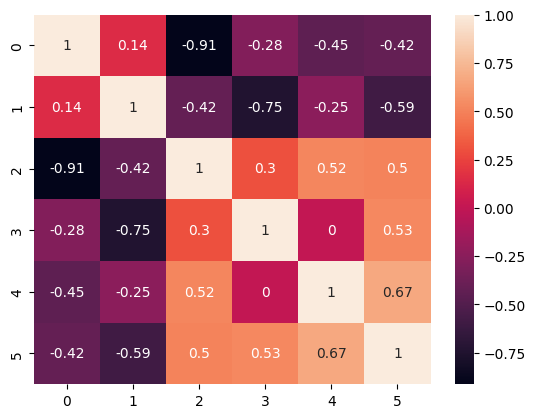

In [ ]:
sns.heatmap(stats.spearmanr(rankss[0].iloc[:10,].to_numpy()).statistic, annot=True)




...
plot.show

In [ ]:
corresponding_topics[0]

Index(['P1_n_0_comodidad_en_el_trabajo', 'P1_n_1_compromiso_con_la_empresa',
       'P1_n_2_buen_ambiente_laboral', 'P1_n_3_valores_de_la_empresa',
       'P1_n_4_estabilidad_y_crecimiento_laboral',
       'P1_n_5_prestaciones_y_sueldo'],
      dtype='object')

In [ ]:
import seaborn as sns

In [ ]:
new_df

In [ ]:
def print_heatmaps(ranks_corrs, corresponding_topics, significance=1, q=range(6)):
  for i in range(6):
    print("Heatmap for correlation of ranks in topics of question", (i+1))

    g = sns.heatmap(ranks_corrs[i].statistic, annot=True)
    # g.set_xticklabels(corresponding_topics[i])
    print(corresponding_topics[i])
    plt.show()
    if significance:
      print("Significance:")
      g = sns.heatmap(ranks_corrs[i].pvalue, annot=True)
    plt.show()

  return None

# sns.heatmap(rank0_corr.statistic, annot=True)

Heatmap for correlation of ranks in topics of question 1
Index(['P1_n_0_comodidad_en_el_trabajo', 'P1_n_1_compromiso_con_la_empresa',
       'P1_n_2_buen_ambiente_laboral', 'P1_n_3_valores_de_la_empresa',
       'P1_n_4_estabilidad_y_crecimiento_laboral',
       'P1_n_5_prestaciones_y_sueldo'],
      dtype='object')


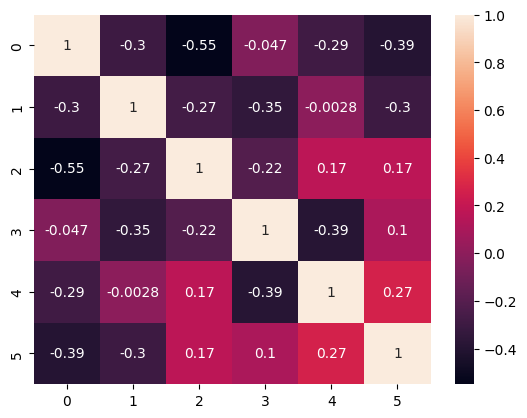

Significance:


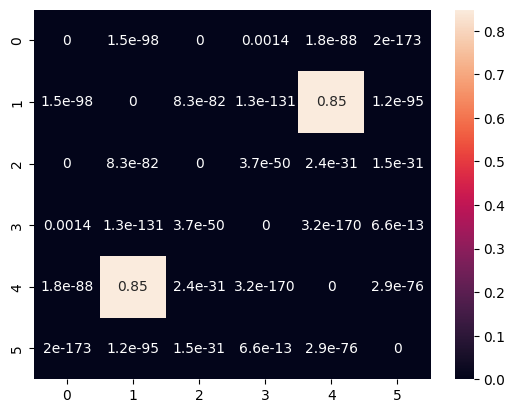

Heatmap for correlation of ranks in topics of question 2
Index(['P2_n_0_exigencia_laboral_y_trato_jefes', 'P2_n_1_horarios_y_sueldo',
       'P2_n_2_carga_de_trabajo_y_tiempo_personal',
       'P2_n_3_busqueda_de_mejores_prestaciones',
       'P2_n_4_disgusto_con_actividades_laborales',
       'P2_n_5_falta_de_compromiso_y_responsabilidad'],
      dtype='object')


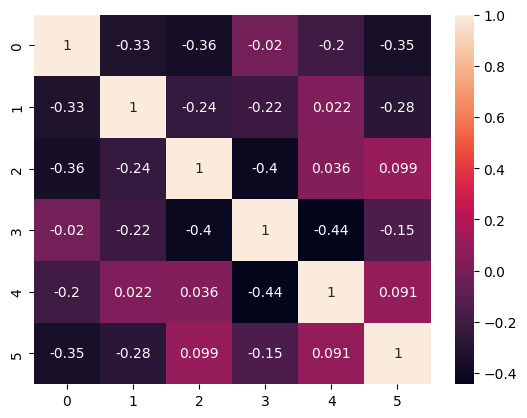

Significance:


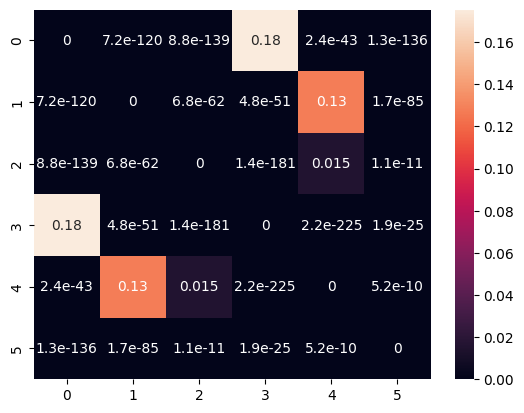

Heatmap for correlation of ranks in topics of question 3
Index(['P3_n_0_exigencia_laboral_y_trato_jefes', 'P3_n_1_horarios_y_sueldo',
       'P3_n_2_carga_de_trabajo_y_tiempo_personal',
       'P3_n_3_busqueda_de_mejores_prestaciones',
       'P3_n_4_disgusto_con_actividades_laborales',
       'P3_n_5_falta_de_compromiso_o_mejores_ofertas'],
      dtype='object')


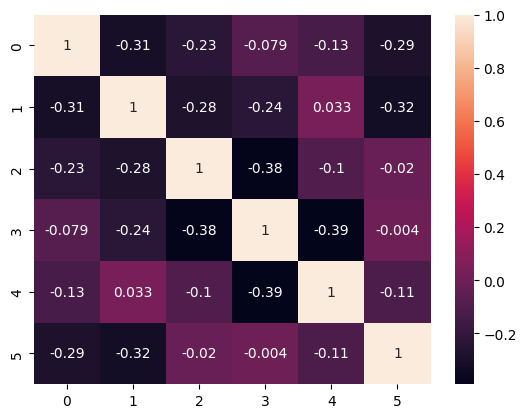

Significance:


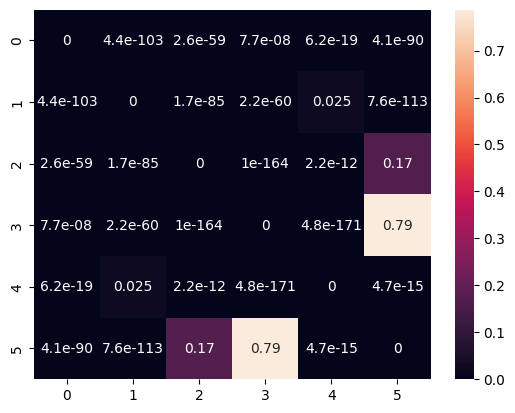

Heatmap for correlation of ranks in topics of question 4
Index(['P4_n_0_competencia_laboral_sueldos_horarios',
       'P4_n_1_gestion_del_centro_y_metas',
       'P4_n_2_poca_afluencia_de_clientes',
       'P4_n_3_ubicacion_tienda_y_competencia_zona',
       'P4_n_4_cultura_de_trabajo_y_equipo', 'P4_n_5_falta_de_personal'],
      dtype='object')


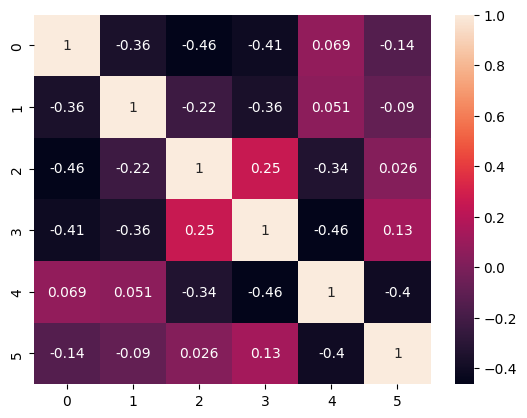

Significance:


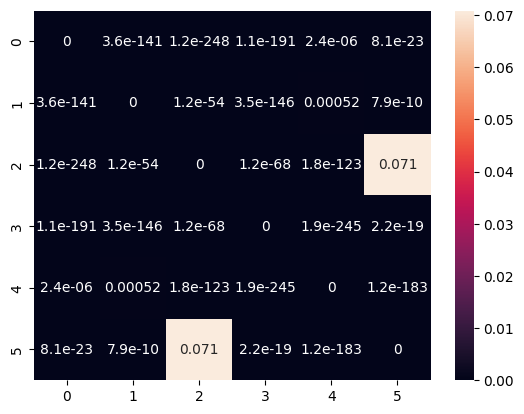

Heatmap for correlation of ranks in topics of question 5
Index(['P5_n_0_seguimiento_y_entrenamiento_colaborador',
       'P5_n_1_apoyo_gerentes_y_desarrollo', 'P5_n_2_incentivos_para_metas',
       'P5_n_3_bienestar_del_colaborador',
       'P5_n_4_mejores_prestaciones_y_sueldos',
       'P5_n_5_mejora_horarios_y_sueldo'],
      dtype='object')


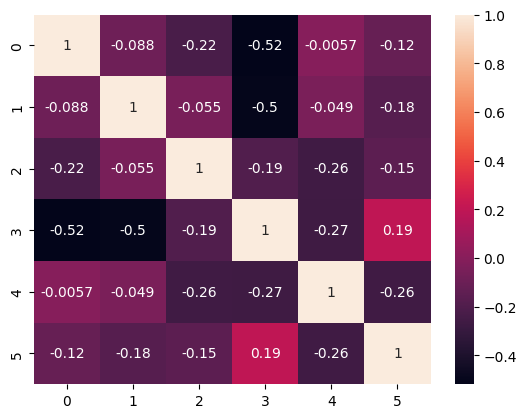

Significance:


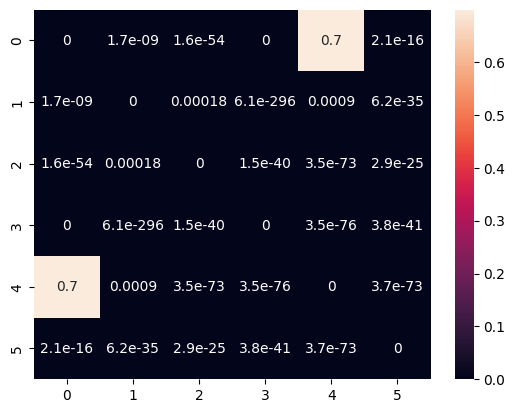

Heatmap for correlation of ranks in topics of question 6
Index(['P6_n_0_sin_comentarios_o_tema_horarios', 'P6_n_1_sueldo_e_incentivos',
       'P6_n_2_todo_bien_sin_comentarios',
       'P6_n_3_temas_generales_colaboradores',
       'P6_n_4_trabajo_personal_y_metas',
       'P6_n_5_relacion_gerentes_colaboradores'],
      dtype='object')


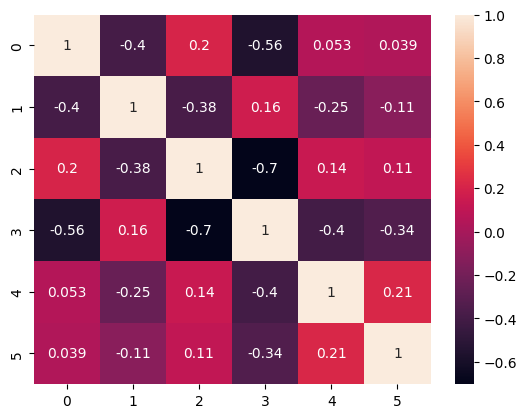

Significance:


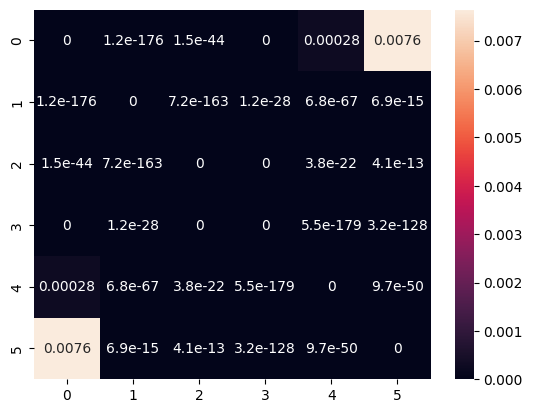

In [ ]:
print_heatmaps(ranks_corrs, corresponding_topics, significance=1, q=[0])

<Axes: >

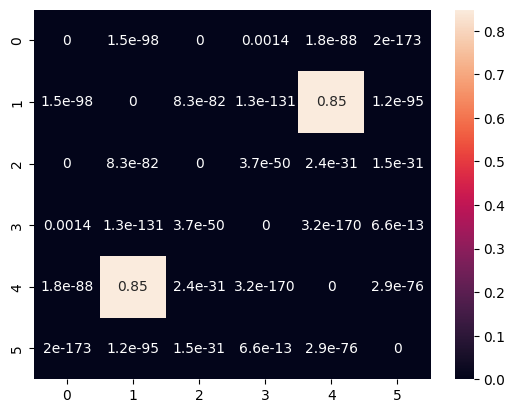

In [ ]:
sns.heatmap(rank0_corr.pvalue, annot=True)

[Text(0, 0.5, 'Row 1'),
 Text(0, 1.5, 'Row 2'),
 Text(0, 2.5, 'Row 3'),
 Text(0, 3.5, 'Row 4'),
 Text(0, 4.5, 'Row 5'),
 Text(0, 5.5, 'Row 6'),
 Text(0, 6.5, 'Row 7'),
 Text(0, 7.5, 'Row 8'),
 Text(0, 8.5, 'Row 9'),
 Text(0, 9.5, 'Row 10')]

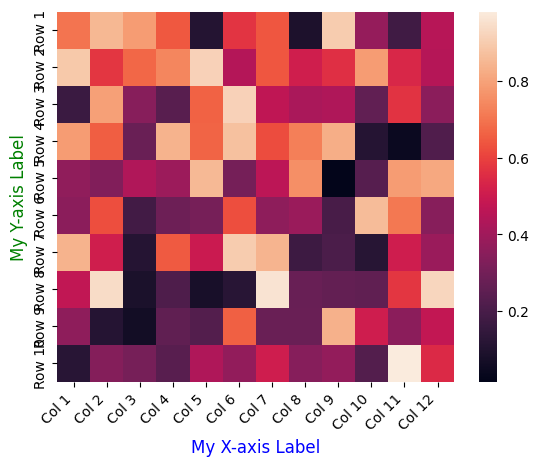

In [ ]:
import numpy as np
data = np.random.rand(10, 12)

# Create the heatmap and store the Axes object
ax = sns.heatmap(data)

# Set the X and Y axis labels
ax.set_xlabel("My X-axis Label", fontsize=12, color='blue')
ax.set_ylabel("My Y-axis Label", fontsize=12, color='green')

# Optionally, you can also customize the tick labels
ax.set_xticklabels([f"Col {i+1}" for i in range(data.shape[1])], rotation=45, ha='right')
ax.set_yticklabels([f"Row {i+1}" for i in range(data.shape[0])])

In [ ]:
corresponding_topics[0]

In [ ]:
corresponding_topics[0].tolist()